In [8]:
import sys
import os
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from pycgp_finalclass.Config import CGPConfig
from pycgp_finalclass.ES import ES
from pycgp_finalclass.Evaluator import EvaluatorSin, Binary_Classifier, Regressor, MultiClassClassifier,Binary_Regressor
from pycgp_finalclass.Node import Node
from pycgp_finalclass.Mutation import Golden_mutation
from pycgp_finalclass.Function import Func
from pycgp_finalclass.Function_library import *
from pycgp_finalclass.Genome import CGPGenome

In [9]:
def build_funcLib(): #Define the function used
    return [Func(f_sum, 'sum', 2, 0),
            Func(f_aminus, 'aminus', 2, 0),
            Func(f_mult, 'mult', 2, 0),
            Func(f_exp, 'exp', 2, 0),
            Func(f_abs, 'abs', 1, 0),
            Func(f_sqrt, 'sqrt', 1, 0),
            Func(f_sqrtxy, 'sqrtxy', 2, 0),
            Func(f_squared, 'squared', 1, 0),
            Func(f_pow, 'pow', 2, 0),
            Func(f_one, 'one', 0, 0),
            Func(f_zero, 'zero', 0, 0),
            Func(f_const, 'const', 0, 1),
            Func(f_inv, 'inv', 1, 0),
            Func(f_gt, 'gt', 2, 0),
            Func(safe_div, 'div', 2, 0),
            Func(f_asin, 'asin', 1, 0),
            Func(f_acos, 'acos', 1, 0),
            Func(f_atan, 'atan', 1, 0),
            Func(f_sin, 'sin', 1, 0),
            Func(f_min, 'min', 2, 0),
            Func(f_max, 'max', 2, 0),
            Func(f_round, 'round', 1, 0),
            Func(f_floor, 'floor', 1, 0),
            Func(f_ceil, 'ceil', 1, 0)
            ]
functions = build_funcLib()

Starting fitness 0.4609


Gen 9803 | Best: 0.6027: 100%|██████████| 10000/10000 [41:16<00:00,  4.04gen/s]    



Best Train fitness achieved: 0.6027

Test fitness: 0.5824
n53 = sum(x20, x0)
n54 = ceil(x38)
n55 = sin(n54)
n56 = sin(n55)
n57 = aminus(x24, n53)
n58 = min(n55, n53)
n59 = inv(n53)
n60 = mult(n54, n54)
n61 = squared(n58)
n62 = inv(x1)
n63 = sin(n55)
n64 = asin(n56)
n65 = min(n55, x41)
n66 = sin(n57)
n67 = sin(n62)
n68 = mult(x5, n65)
n69 = floor(n56)
n70 = inv(n60)
n71 = inv(n65)
n72 = atan(n68)
n73 = max(x32, n72)
n74 = max(n58, n67)
n75 = atan(n73)
n76 = squared(n57)
n77 = inv(n56)
n78 = ceil(n74)
n79 = pow(n76, n54)
n80 = sum(x5, n67)
n81 = ceil(n75)
n82 = exp(n71, n64)
Outputs: n75

Unrolled output expression 0:
atan(max(x32, atan(mult(x5, min(sin(ceil(x38)), x41)))))



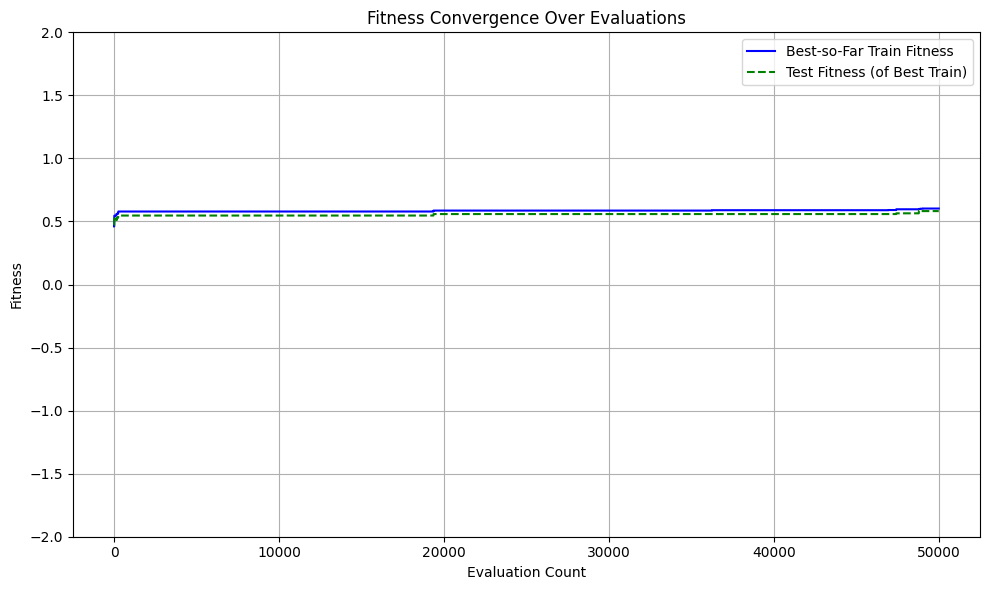

c:\Users\pauls\Bureau\Cours_2IS_M2\stage\pyCGP2.0\pycgp_finalclass\Genome.py:243: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


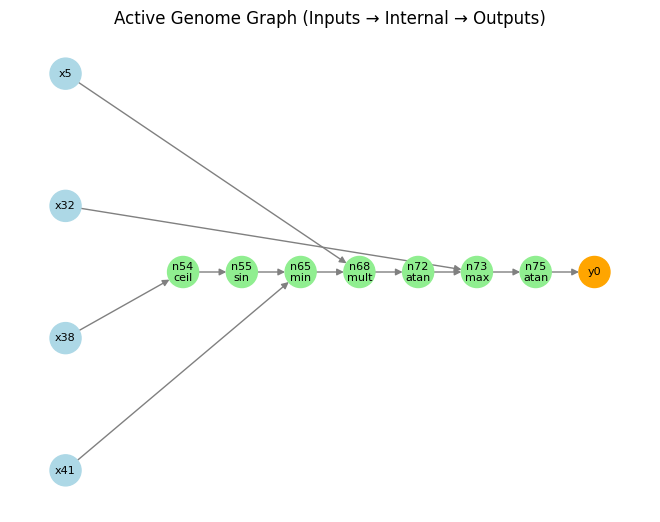

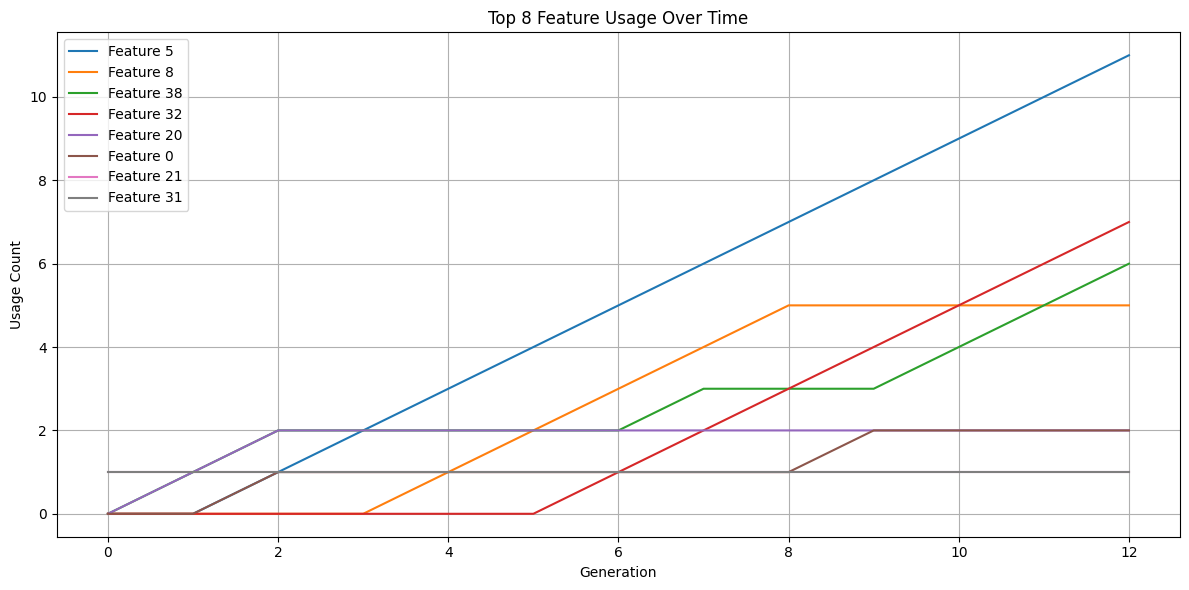

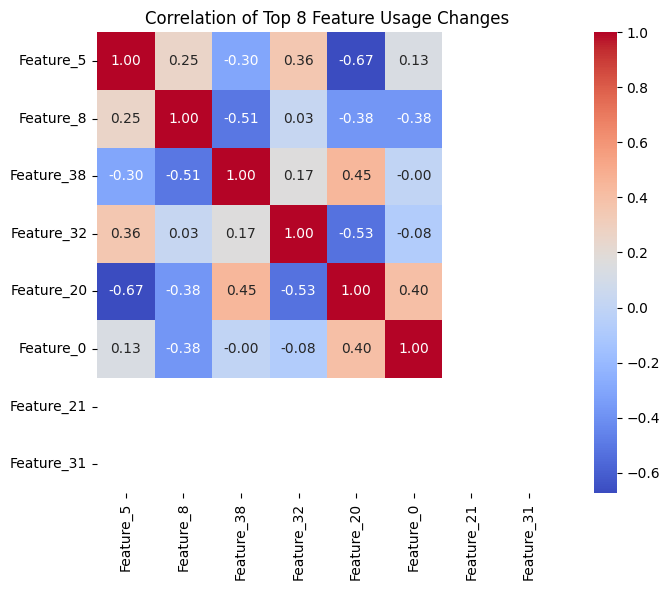

In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Charger le fichier CSV avec le bon séparateur
file_path = 'datasets/Audio.xlsx'
df = pd.read_excel(file_path)

sex_mapping = {
    'F': 0,
    'M': 1,
}

# Appliquer la transformation
df['sex_num'] = df['sex'].map(sex_mapping)

# Cible
y = df['sex_num']

# Supprimer la colonne cible 'age_class' (vous pouvez aussi la sauvegarder si besoin)
X = df.drop(columns=["sex","ind","sex_num","ampl"])

# Encoder toutes les colonnes non-numériques (de type object) en entiers
for col in X.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# Vérification que tout est bien en float
X = X.astype(float)




scaler = MinMaxScaler(feature_range=(-1, 1))
X_scaled = scaler.fit_transform(X)



evaluator2 = Binary_Classifier(X_scaled, y)

#Initialise config + Evaluator + mutation 
CGP_config = CGPConfig(num_inputs=X.shape[1], num_nodes=30, num_outputs=1, input_node_chance=0.4, const_min=-1, const_max=1, function_set=functions)

mutationcgp_golden = Golden_mutation(CGP_config,input_node_mutation_rate=0.2, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1,output_node_mutation_rate=0.5)

ES_cgp = ES(evaluator2, lam=5,parent_factory=lambda: CGPGenome.create_genome(CGP_config),mutation = mutationcgp_golden,config = CGP_config)
best_genome = ES_cgp.evolve(n_generations=10000, early_stopping=5000,early_switch=10000, verbose=True)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer

# --- Split the dataset ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# --- Optional: Standardize features for models that benefit from it (SVM, KNN, Ridge, etc.) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Remplacer les NaN par la moyenne de chaque colonne
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)  # X est ton DataFrame sans 'age_class'

X_train_imputed = imputer.fit_transform(X_train_scaled)
X_test_imputed = imputer.transform(X_test_scaled)



# --- Define classification models ---
models = {
    'Logistic Regression': LogisticRegression(max_iter=100000),
    'Ridge Classifier': RidgeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Support Vector Classifier': SVC(),
    'KNN Classifier': KNeighborsClassifier()
}

# --- Evaluate accuracy for each model ---
results = {}

for name, model in models.items():
    if name in ['Support Vector Classifier', 'KNN Classifier', 'Ridge Classifier']:
        model.fit(X_train_imputed, y_train)
        y_pred = model.predict(X_test_imputed)
    else:
        model.fit(X_train_imputed, y_train)
        y_pred = model.predict(X_test_imputed)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: Accuracy = {acc:.4f}")

# --- Show sorted results ---
df_results = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy'])
df_results = df_results.sort_values('Accuracy', ascending=False)
print("\n=== Sorted Results ===")
print(df_results)


print("\n=== CGP result ===")
print(f"CGP: accuracy score = {evaluator2.evaluate(best_genome)}")


Logistic Regression: Accuracy = 0.5118
Ridge Classifier: Accuracy = 0.5059
Random Forest: Accuracy = 0.6235
Gradient Boosting: Accuracy = 0.6294
Support Vector Classifier: Accuracy = 0.4882
KNN Classifier: Accuracy = 0.5588

=== Sorted Results ===
                           Accuracy
Gradient Boosting          0.629412
Random Forest              0.623529
KNN Classifier             0.558824
Logistic Regression        0.511765
Ridge Classifier           0.505882
Support Vector Classifier  0.488235

=== CGP result ===
CGP: accuracy score = (0.6026587887740029, 0.5823529411764706)


Logistic Regression: Accuracy = 0.5118
Ridge Classifier: Accuracy = 0.5059
Random Forest: Accuracy = 0.6412
Gradient Boosting: Accuracy = 0.6000
Support Vector Classifier: Accuracy = 0.4882
KNN Classifier: Accuracy = 0.5588

=== Sorted Results ===
                           Accuracy
Random Forest              0.641176
Gradient Boosting          0.600000
KNN Classifier             0.558824
Logistic Regression        0.511765
Ridge Classifier           0.505882
Support Vector Classifier  0.488235

=== CGP result ===
CGP: accuracy score = (0.6026587887740029, 0.5823529411764706)


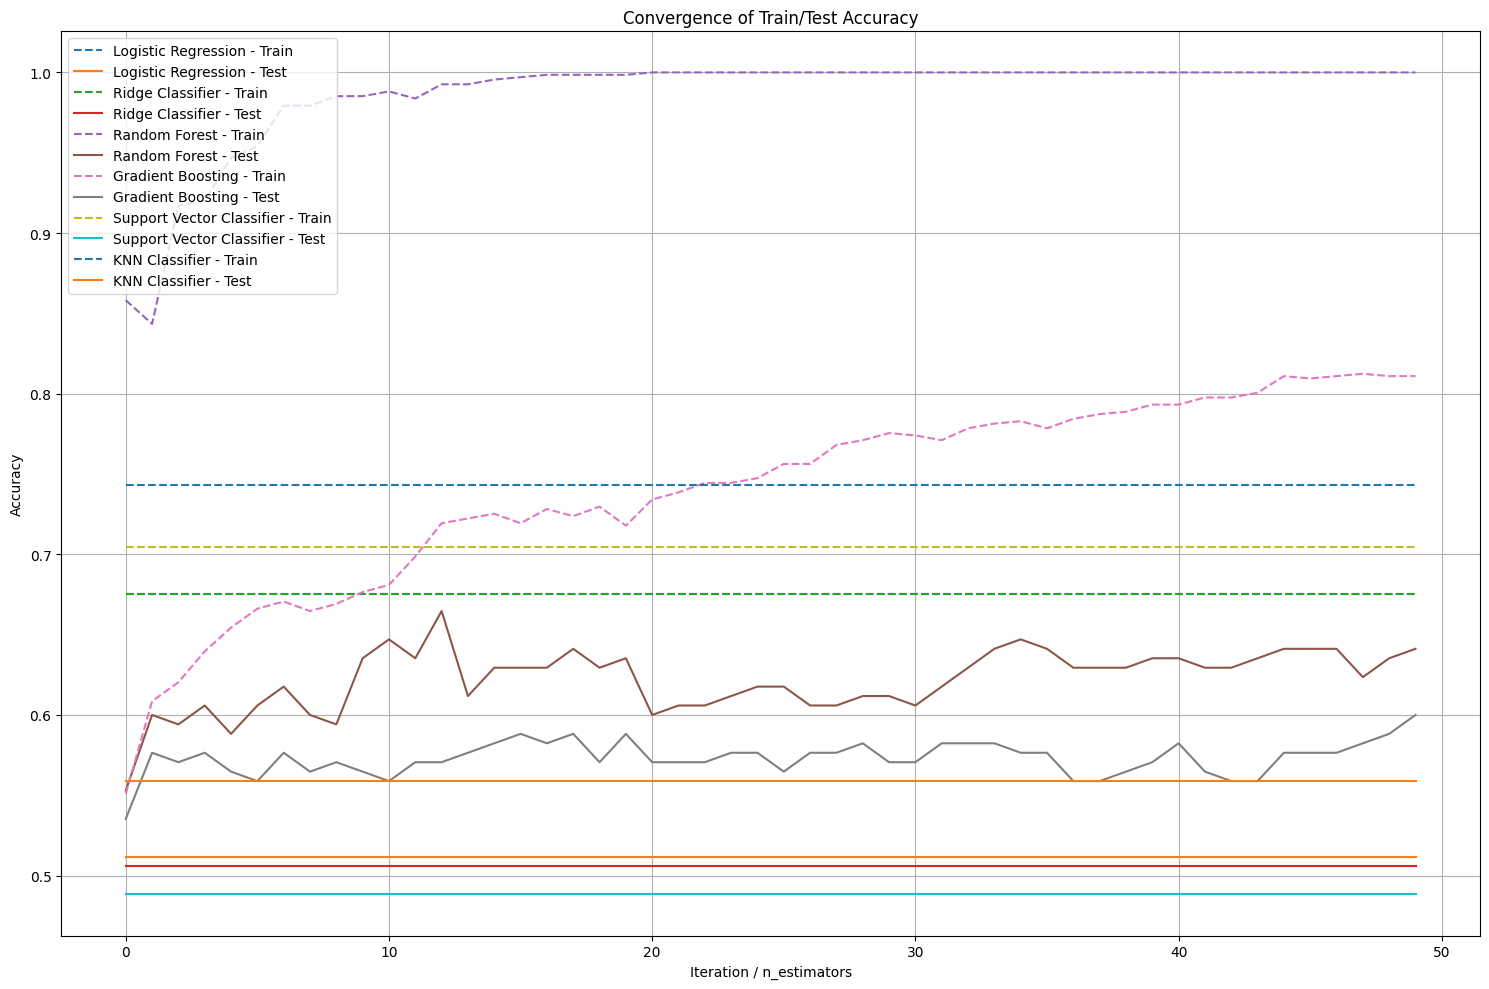

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer

# --- Data Preprocessing ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train_scaled)
X_test_imputed = imputer.transform(X_test_scaled)

# --- Models ---
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, warm_start=True),
    'Ridge Classifier': RidgeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=1, warm_start=True, ),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=1, warm_start=True),
    'Support Vector Classifier': SVC(),
    'KNN Classifier': KNeighborsClassifier()
}

results = {}
convergence_data = {}

# --- Training Loop with Convergence Tracking ---
for name, model in models.items():
    train_scores = []
    test_scores = []

    if name in ['Logistic Regression', 'Random Forest', 'Gradient Boosting']:
        for i in range(1, 51):  # Simulate 50 steps
            if name in ['Random Forest', 'Gradient Boosting']:
                model.n_estimators = i
            model.fit(X_train_imputed, y_train)
            train_acc = model.score(X_train_imputed, y_train)
            test_acc = model.score(X_test_imputed, y_test)
            train_scores.append(train_acc)
            test_scores.append(test_acc)
    else:
        model.fit(X_train_imputed, y_train)
        train_acc = model.score(X_train_imputed, y_train)
        test_acc = model.score(X_test_imputed, y_test)
        train_scores = [train_acc] * 50
        test_scores = [test_acc] * 50

    acc = test_scores[-1]
    results[name] = acc
    convergence_data[name] = (train_scores, test_scores)

    print(f"{name}: Accuracy = {acc:.4f}")

# --- Sorted Results ---
df_results = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy'])
df_results = df_results.sort_values('Accuracy', ascending=False)
print("\n=== Sorted Results ===")
print(df_results)

# --- CGP Output ---
print("\n=== CGP result ===")
print(f"CGP: accuracy score = {evaluator2.evaluate(best_genome)}")

# --- Convergence Plots ---
plt.figure(figsize=(15, 10))
for name, (train_scores, test_scores) in convergence_data.items():
    plt.plot(train_scores, label=f'{name} - Train', linestyle='--')
    plt.plot(test_scores, label=f'{name} - Test')

plt.xlabel('Iteration / n_estimators')
plt.ylabel('Accuracy')
plt.title('Convergence of Train/Test Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


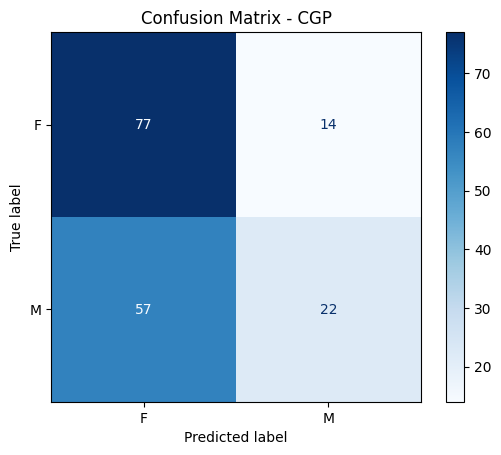

              precision    recall  f1-score   support

           F       0.57      0.85      0.68        91
           M       0.61      0.28      0.38        79

    accuracy                           0.58       170
   macro avg       0.59      0.56      0.53       170
weighted avg       0.59      0.58      0.54       170



In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Get predictions and ground truth
y_pred = evaluator2.predict(best_genome, on="test")
y_true = np.array(evaluator2.y_test).flatten()

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["F", "M"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - CGP")
plt.grid(False)
plt.show()

# print precision, recall, F1
print(classification_report(y_true, y_pred, target_names=["F", "M"]))



=== SHAP Summary for Logistic Regression ===


c:\Users\pauls\Bureau\Cours_2IS_M2\stage\pyCGP2.0\.venv\Lib\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


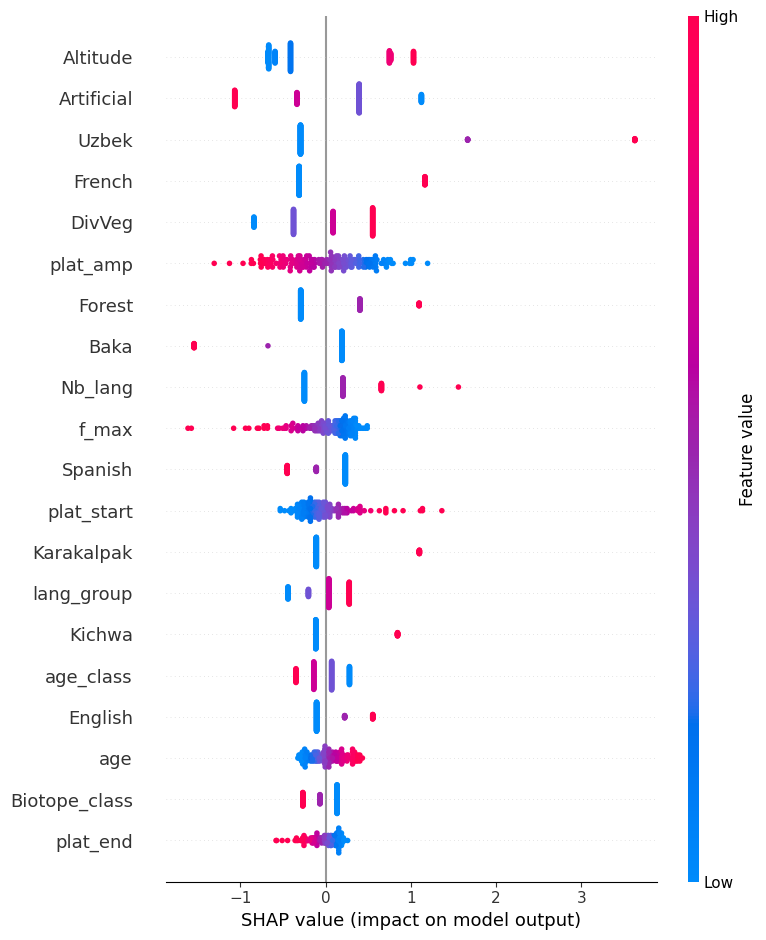


=== SHAP Summary for Ridge Classifier ===


c:\Users\pauls\Bureau\Cours_2IS_M2\stage\pyCGP2.0\.venv\Lib\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


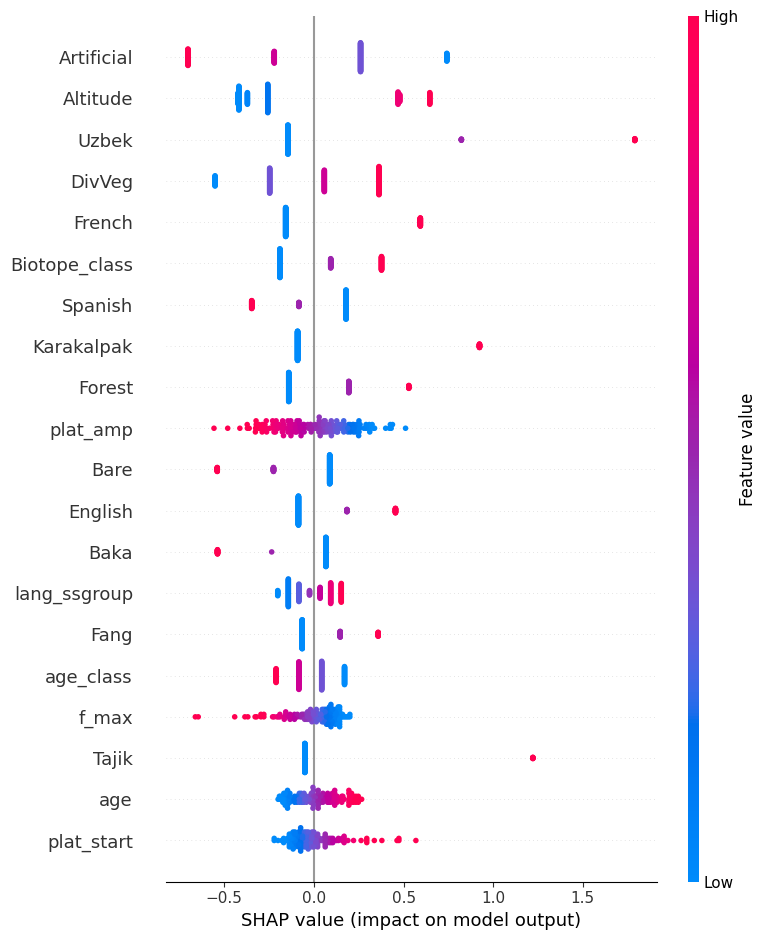


=== SHAP Summary for Random Forest ===
Error generating SHAP for Random Forest: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. This check failed because for one of the samples the sum of the SHAP values was 0.540000, while the model output was 0.560000. If this difference is acceptable you can set check_additivity=False to disable this check.

=== SHAP Summary for Gradient Boosting ===


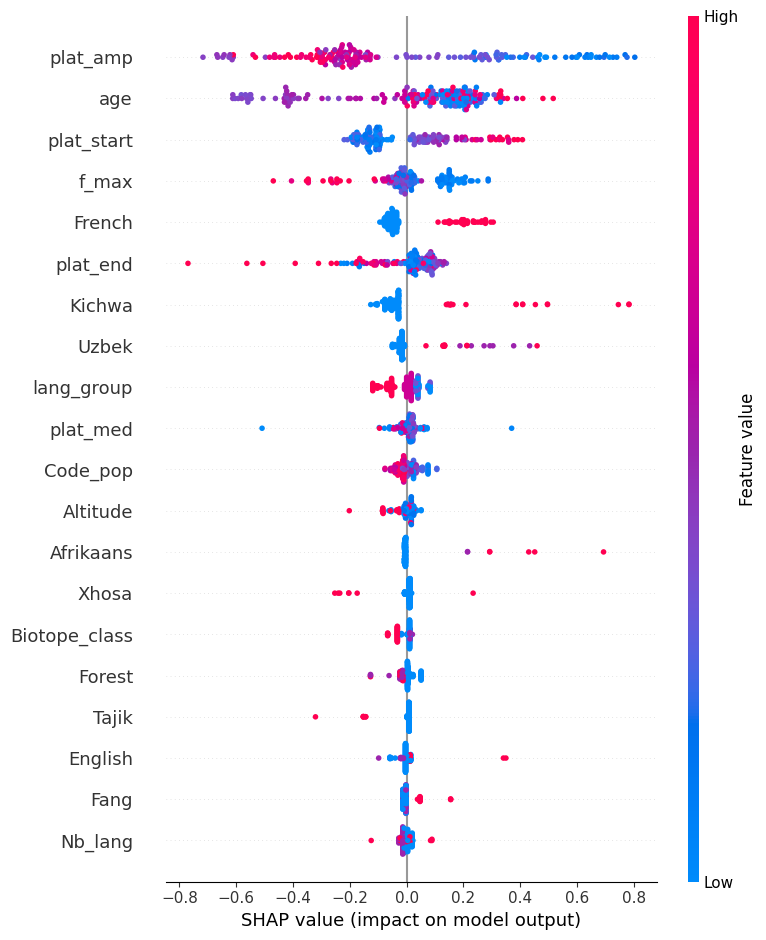

Skipping SHAP for Support Vector Classifier (not supported)
Skipping SHAP for KNN Classifier (not supported)


In [14]:
import shap

# Use original column names for plotting
feature_names = X.columns
X_sample = pd.DataFrame(X_test_imputed, columns=feature_names)

# Dictionary to map model type to SHAP explainer
model_explainers = {
    'Logistic Regression': shap.LinearExplainer,
    'Ridge Classifier': shap.LinearExplainer,
    'Random Forest': shap.TreeExplainer,
    'Gradient Boosting': shap.TreeExplainer
}

# SHAP summary plots
for name, model in models.items():
    if name not in model_explainers:
        print(f"Skipping SHAP for {name} (not supported)")
        continue

    print(f"\n=== SHAP Summary for {name} ===")
    try:
        # Use appropriate explainer
        explainer_class = model_explainers[name]
        explainer = explainer_class(model, X_sample, feature_perturbation="interventional")
        shap_values = explainer(X_sample)

        # Plot SHAP summary
        shap.summary_plot(shap_values, X_sample, feature_names=feature_names)
    except Exception as e:
        print(f"Error generating SHAP for {name}: {e}")
